In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ixplore import IXPLORE
from ixplore.visualization import clean_axis

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [2]:
# Load data and pretrained model
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
reactions = reactions / reactions.max().max()

pretrained_embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
pretrained_models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)

In [3]:
# Fit model with pretrained embedding and models
xplore = IXPLORE(reactions, pretrained_embedding=pretrained_embedding, pretrained_models=pretrained_models)

ixplore - INFO - 2026-03-14 12:30:55 - Number of users for model: 250
ixplore - INFO - 2026-03-14 12:30:55 - Number of items: 70
ixplore - INFO - 2026-03-14 12:30:55 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 12:30:55 - Grid created with resolution 200x200, total 40000 points
ixplore - INFO - 2026-03-14 12:30:55 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 12:30:55 - Random state set to 0
ixplore - INFO - 2026-03-14 12:30:55 - Used pretrained embedding.
ixplore - INFO - 2026-03-14 12:30:55 - Used pretrained model parameters.


### Generate 30x30 candidate grid and sample responses

In [4]:
# Create a 30x30 evenly spaced grid spanning the model's limits
grid_x = np.linspace(xplore.limits[0], xplore.limits[1], 30)
grid_y = np.linspace(xplore.limits[2], xplore.limits[3], 30)
xx, yy = np.meshgrid(grid_x, grid_y)
candidates = np.column_stack([xx.ravel(), yy.ravel()])  # (900, 2)

# 2D gradient color: red = x position, blue = y position
cx_norm = (candidates[:, 0] - candidates[:, 0].min()) / (candidates[:, 0].max() - candidates[:, 0].min())
cy_norm = (candidates[:, 1] - candidates[:, 1].min()) / (candidates[:, 1].max() - candidates[:, 1].min())
candidate_colors = np.column_stack([cx_norm, 0.3 * np.ones(len(candidates)), cy_norm])

# Sample responses for all candidates using the fitted model
candidate_reactions = xplore.predict(candidates)
candidate_reactions = pd.DataFrame(candidate_reactions, columns=reactions.columns)
print(f"Generated {len(candidates)} candidates with {candidate_reactions.shape[1]} responses each")

Generated 900 candidates with 70 responses each


### Re-embed candidates from their sampled responses

ixplore - INFO - 2026-03-14 12:30:55 - Number of users for model: 900
ixplore - INFO - 2026-03-14 12:30:55 - Number of items: 70
ixplore - INFO - 2026-03-14 12:30:55 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 12:30:55 - Grid created with resolution 200x200, total 40000 points
ixplore - INFO - 2026-03-14 12:30:55 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 12:30:55 - Random state set to 0
ixplore - INFO - 2026-03-14 12:30:55 - Initialized embedding with PCA.
ixplore - INFO - 2026-03-14 12:30:55 - Used pretrained model parameters.


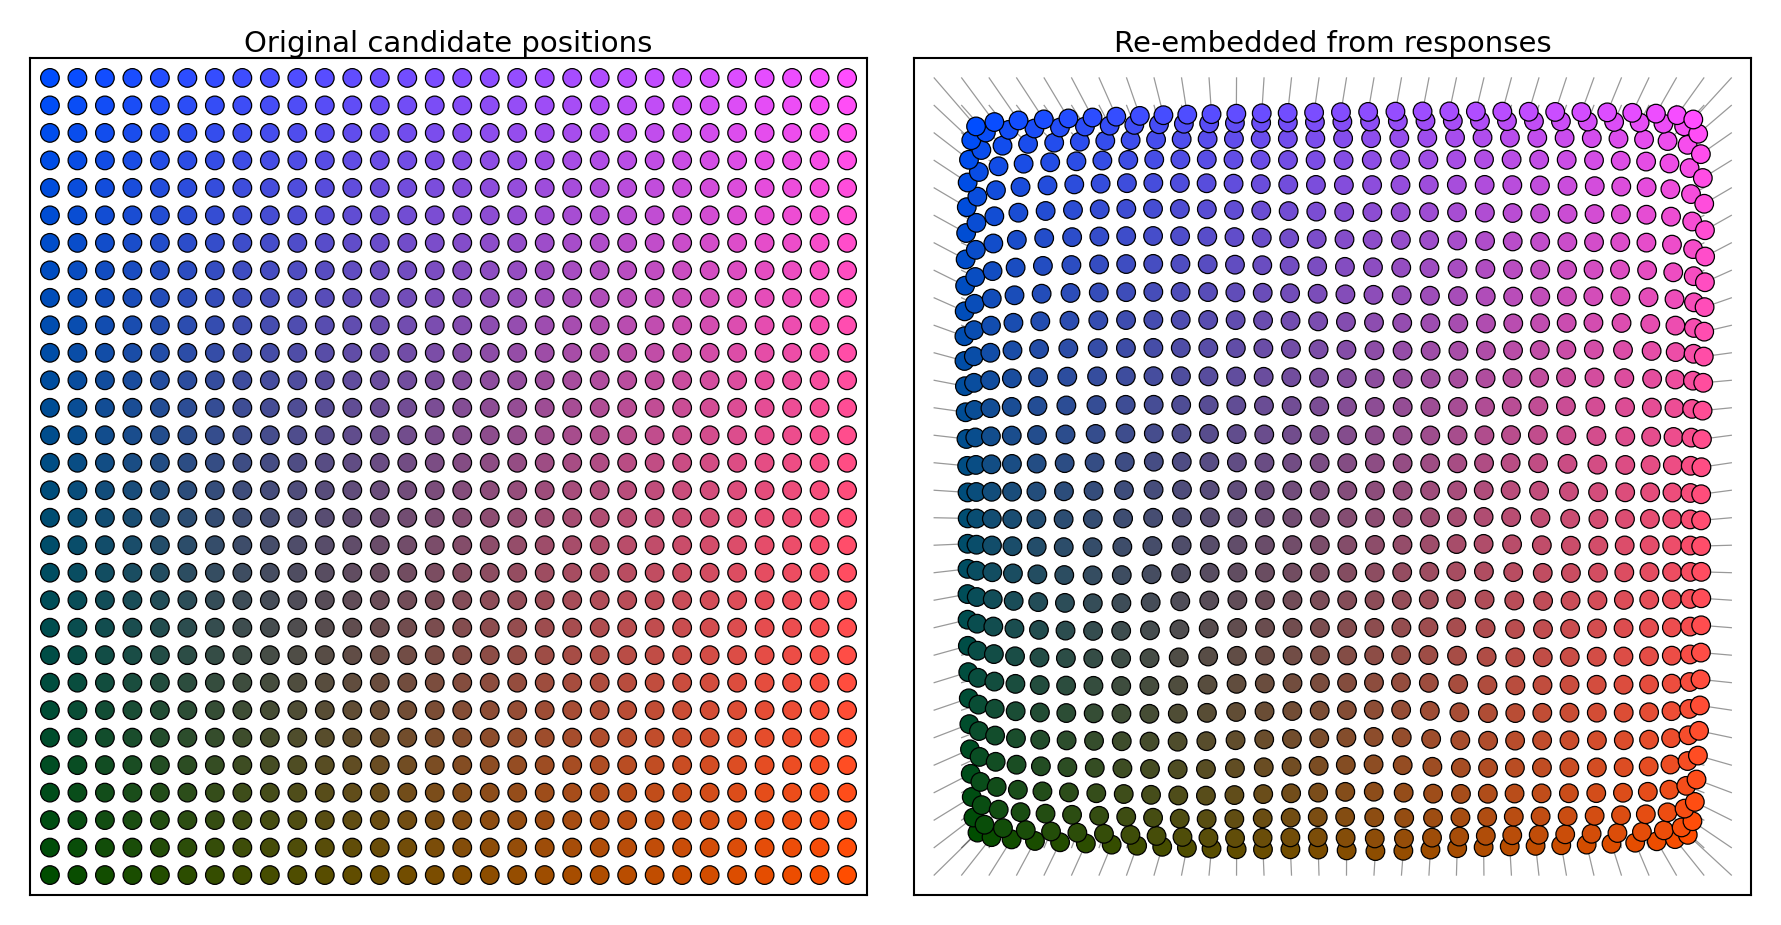

In [5]:
# Plot: original grid positions vs re-embedded positions
candidate_xplore = IXPLORE(candidate_reactions, pretrained_models=xplore.get_item_parameters())
candidate_xplore.fit_posteriors()
reembedded = candidate_xplore.get_embedding().values  # (900, 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# Left: original candidate positions
ax1.scatter(candidates[:, 0], candidates[:, 1], c=candidate_colors, s=20, edgecolors='k', lw=0.3, zorder=2)
clean_axis(ax1, limits=(-1.05, 1.05))
ax1.set_title('Original candidate positions')

# Right: re-embedded positions with lines back to original
for i in range(len(candidates)):
    ax2.plot([candidates[i, 0], reembedded[i, 0]], [candidates[i, 1], reembedded[i, 1]],
             c='k', lw=0.3, alpha=0.4, zorder=1)
ax2.scatter(reembedded[:, 0], reembedded[:, 1], c=candidate_colors, s=20, edgecolors='k', lw=0.3, zorder=2)
clean_axis(ax2, limits=(-1.05, 1.05))
ax2.set_title('Re-embedded from responses')

fig.tight_layout()
fig.savefig('../figures/latent_space_grid.png')

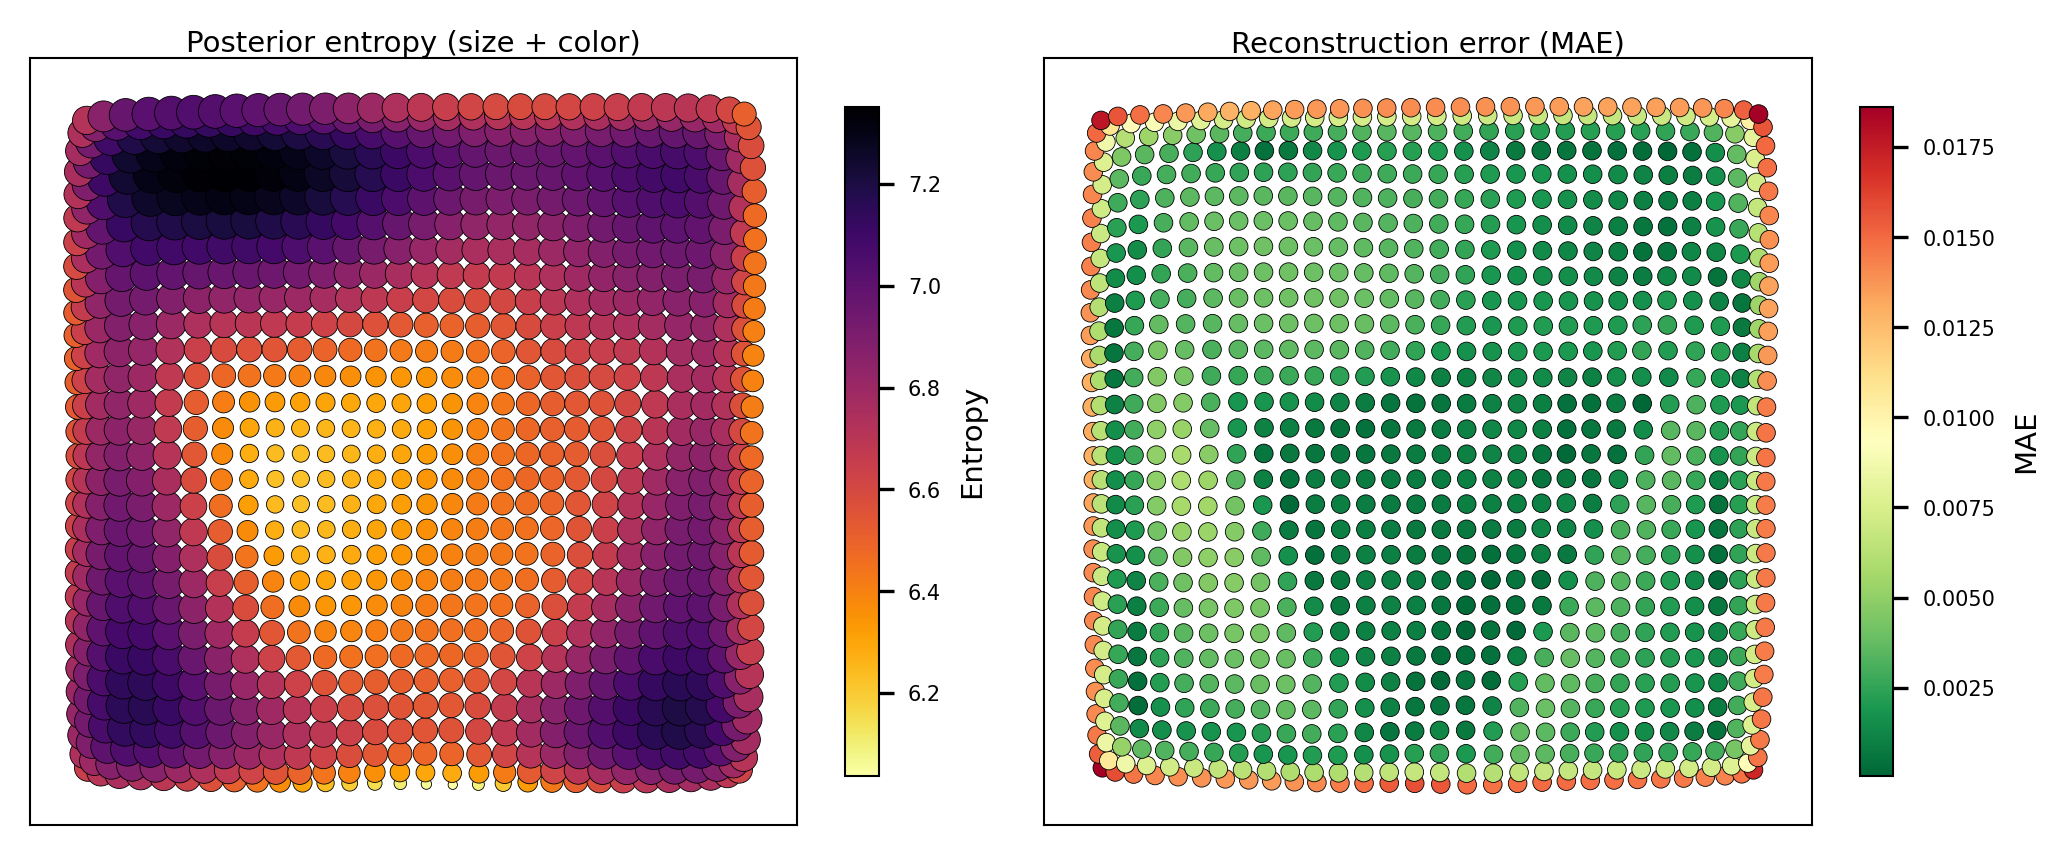

In [6]:
# Compute posterior entropy (uncertainty) and reconstruction error per candidate
posteriors = candidate_xplore.get_posteriors().values  # (900, 40000)
entropy = -np.sum(posteriors * np.log(posteriors + 1e-30), axis=1)

# Reconstruction error: MAE between original candidate responses and predictions from re-embedded positions
reconstructed = candidate_xplore.predict(reembedded)
reconstruction_error = np.mean(np.abs(candidate_reactions.values - reconstructed), axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Left: posterior entropy (uncertainty) by dot size
sizes = 5 + 80 * (entropy - entropy.min()) / (entropy.max() - entropy.min())
sc1 = ax1.scatter(reembedded[:, 0], reembedded[:, 1], c=entropy, s=sizes,
                  cmap='inferno_r', edgecolors='k', lw=0.2, zorder=2)
clean_axis(ax1, limits=(-1.05, 1.05))
ax1.set_title('Posterior entropy (size + color)')
plt.colorbar(sc1, ax=ax1, shrink=0.8, label='Entropy')

# Right: reconstruction error (MAE) by color
sc2 = ax2.scatter(reembedded[:, 0], reembedded[:, 1], c=reconstruction_error, s=20,
                  cmap='RdYlGn_r', edgecolors='k', lw=0.2, zorder=2)
clean_axis(ax2, limits=(-1.05, 1.05))
ax2.set_title('Reconstruction error (MAE)')
plt.colorbar(sc2, ax=ax2, shrink=0.8, label='MAE')

fig.tight_layout()
fig.savefig('../figures/latent_space_diagnostics.png')

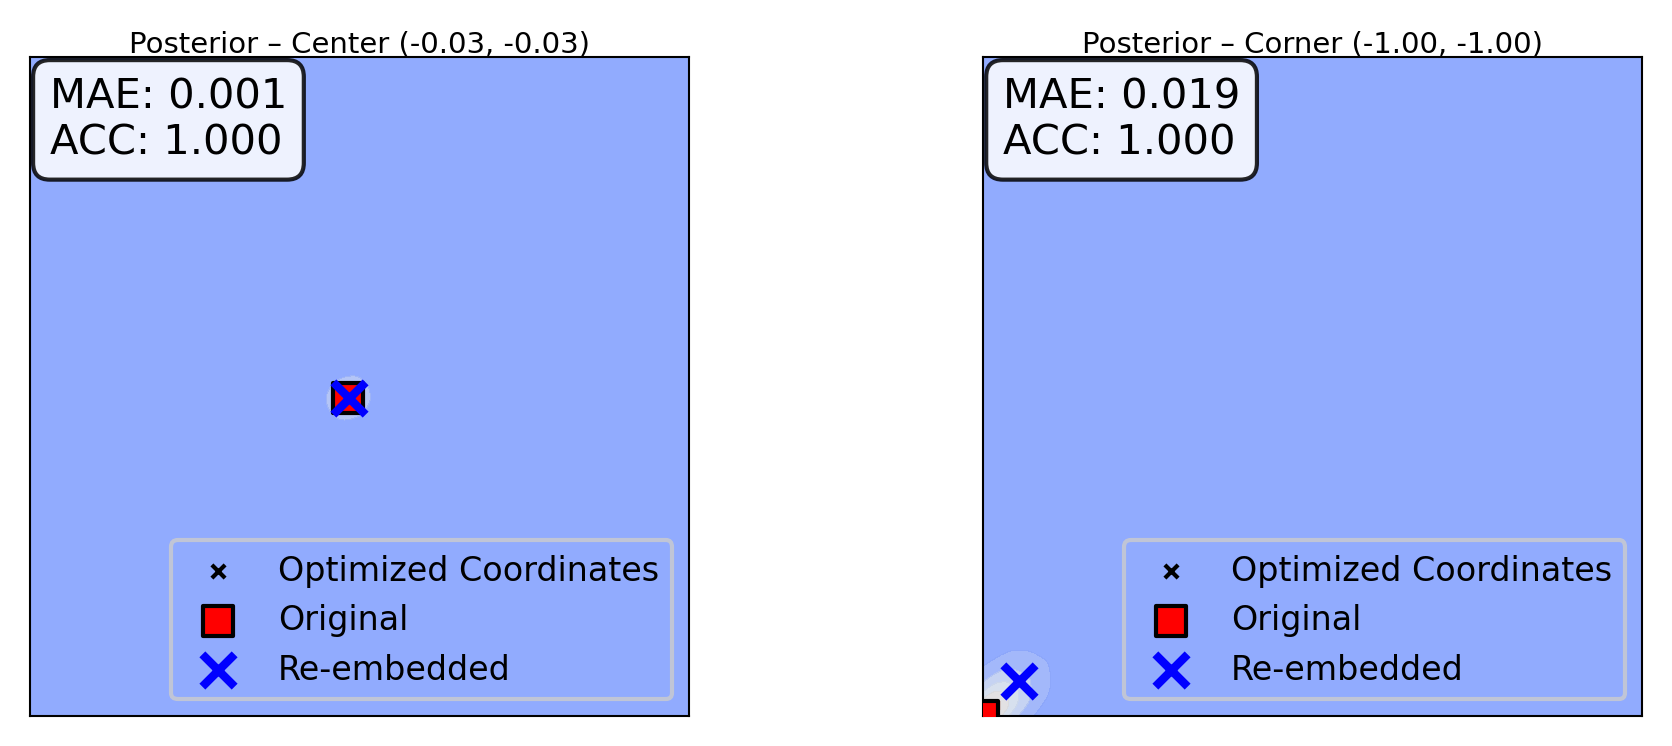

In [7]:
from ixplore.visualization import plot_posterior

# Pick one candidate near center and one from corner
idx_center = 14 * 30 + 14  # grid position ~(0, 0)
idx_corner = 0              # grid position (-1, -1)

fig, (ax1, ax2) = plt.subplots(1, 2)

for ax, idx, label in [(ax1, idx_center, 'Center'), (ax2, idx_corner, 'Corner')]:
    answers = candidate_reactions.iloc[idx]

    # Plot posterior heatmap (no colorbar)
    plot_posterior(candidate_xplore, answers, ax=ax, add_bar=False)

    # Mark original and re-embedded positions
    ax.scatter(*candidates[idx], marker='s', color='red', s=50, edgecolors='k', zorder=6, label='Original')
    ax.scatter(*reembedded[idx], marker='x', color='blue', s=60, lw=2, zorder=6, label='Re-embedded')

    # Compute per-candidate MAE and accuracy
    pred = candidate_xplore.predict(reembedded[idx].reshape(1, -1))[0]
    mae = np.mean(np.abs(answers.values - pred))
    acc = 1 - np.mean(np.abs(answers.values.round() - pred.round()))

    textstr = f'MAE: {mae:.3f}\nACC: {acc:.3f}'
    ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    clean_axis(ax)
    ax.set_title(f'Posterior – {label} ({candidates[idx][0]:.2f}, {candidates[idx][1]:.2f})')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()